# Al-Kindi: The 9th-Century Genius Who Turned Code-Breaking into Science

From Baghdad's House of Wisdom (~801–873), Al-Kindi invented **frequency analysis** — the first systematic way to break monoalphabetic substitution ciphers.

Idea in simple terms:  
Every language has predictable letter frequencies (English: e ~12%, t ~9%, z ~0.1%).  
Count letters in ciphertext → match to known patterns → recover plaintext.

Let's recreate this in Python — no ancient scrolls needed.

![Al-Kindi Portrait](../images/al-kindi_portrait.jpg)
*Al-Kindi (c. 801–873), the "Philosopher of the Arabs"*

## Who Was Al-Kindi?

- Polymath in the Islamic Golden Age (Baghdad)  
- Wrote on philosophy, optics, music, medicine  
- Authored the earliest known cryptography treatise  
- Big idea: Use statistics instead of brute force

![Al-Kindi Portrait](../images/al-kindi_portrait_01.jpg)
*Al-Kindi (c. 801–873), the "Philosopher of the Arabs"*

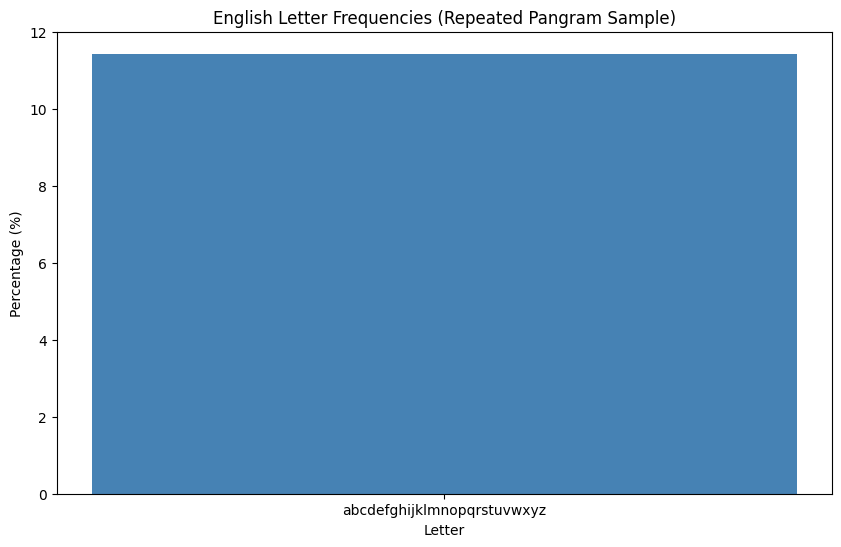

In [4]:
import string
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

# Sample English text
english_text = ("the quick brown fox jumps over the lazy dog " * 30).lower()
english_text = ''.join(c for c in english_text if c in string.ascii_lowercase)

# Count frequencies
english_counts = Counter(english_text)
total = sum(english_counts.values())
english_freq = {letter: (count / total) * 100 for letter, count in english_counts.items()}

# Plot
letters = string.ascii_lowercase
freqs = [english_freq.get(l, 0) for l in letters]

plt.figure(figsize=(10, 6))
plt.bar(letters, freqs, color='steelblue')
plt.title("English Letter Frequencies (Repeated Pangram Sample)")
plt.xlabel("Letter")
plt.ylabel("Percentage (%)")
plt.show()


In [5]:
import random

random.seed(42)  # the answer to everything haha

alphabet = list(string.ascii_lowercase)
mapping = alphabet.copy()
random.shuffle(mapping)
sub_dict = dict(zip(alphabet, mapping))

def encrypt(text):
    text = text.lower()
    return ''.join(sub_dict.get(c, c) for c in text if c in sub_dict)

plaintext = "the quick brown fox jumps over the lazy dog"
ciphertext = encrypt(plaintext)

print("Plaintext: ", plaintext)
print("Ciphertext:", ciphertext)

Plaintext:  the quick brown fox jumps over the lazy dog
Ciphertext: ektcvpjlmrxiogxawvbnyxhtrektsqudzxf


In [6]:
cipher_clean = ''.join(c for c in ciphertext.lower() if c in string.ascii_lowercase)
cipher_counts = Counter(cipher_clean)
total_cipher = sum(cipher_counts.values())
cipher_freq = {letter: (count / total_cipher) * 100 for letter, count in cipher_counts.items()}

# Comparison table (top 12)
comparison = []
for letter in sorted(string.ascii_lowercase, key=lambda l: english_freq.get(l, 0), reverse=True)[:12]:
    comparison.append({
        'letter': letter,
        'english_%': round(english_freq.get(letter, 0), 1),
        'cipher_%': round(cipher_freq.get(letter, 0), 1)
    })

import pandas as pd
print(pd.DataFrame(comparison))

   letter  english_%  cipher_%
0       o       11.4       2.9
1       e        8.6       5.7
2       h        5.7       2.9
3       r        5.7       5.7
4       t        5.7       8.6
5       u        5.7       2.9
6       a        2.9       2.9
7       b        2.9       2.9
8       c        2.9       2.9
9       d        2.9       2.9
10      f        2.9       2.9
11      g        2.9       2.9


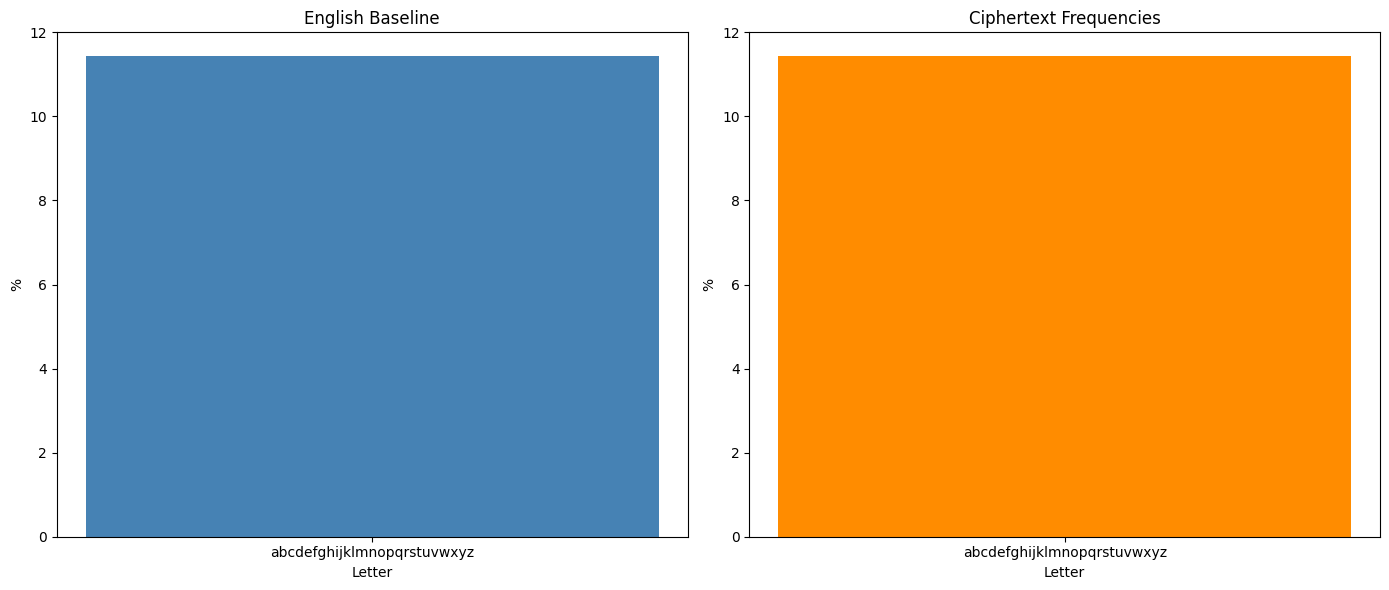

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.bar(letters, freqs, color='steelblue')
ax1.set_title("English Baseline")
ax1.set_xlabel("Letter")
ax1.set_ylabel("%")

cipher_freqs = [cipher_freq.get(l, 0) for l in letters]
ax2.bar(letters, cipher_freqs, color='darkorange')
ax2.set_title("Ciphertext Frequencies")
ax2.set_xlabel("Letter")
ax2.set_ylabel("%")

plt.tight_layout()
plt.show()

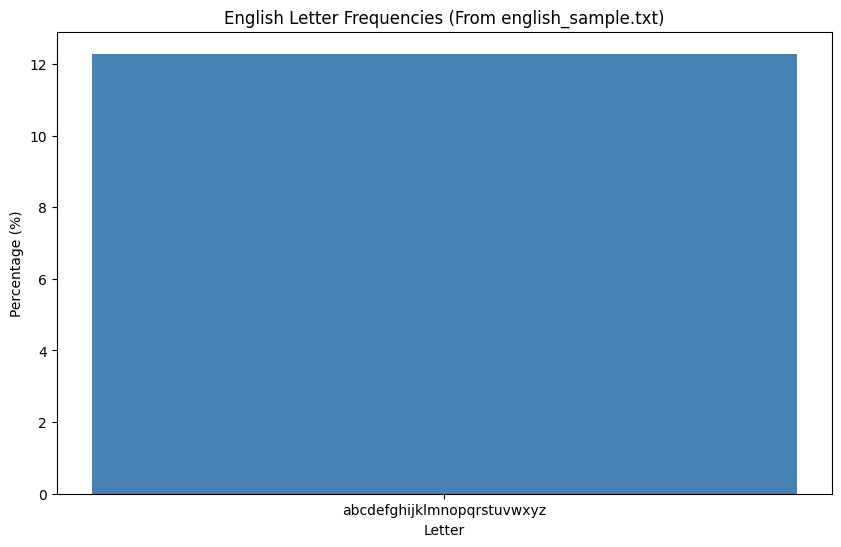

Loaded English sample text successfully!
Length: 3638 characters

Top 10 English letters:
  e: 12.29%
  t: 10.17%
  i: 8.05%
  a: 7.92%
  o: 7.28%
  n: 6.90%
  r: 6.43%
  s: 5.36%
  c: 5.11%
  l: 5.00%


In [8]:
# Load real text from file
# Go up one level from notebook/ to al-kindi/, then into data/
with open("../data/english_sample.txt", "r", encoding="utf-8") as f:
    english_text = f.read().lower()

# Clean: keep only lowercase letters
english_text = ''.join(c for c in english_text if c in string.ascii_lowercase)

# Count frequencies
english_counts = Counter(english_text)
total = sum(english_counts.values())
english_freq = {letter: (count / total) * 100 for letter, count in english_counts.items()}

# Plot (same as before)
letters = string.ascii_lowercase
freqs = [english_freq.get(l, 0) for l in letters]

plt.figure(figsize=(10, 6))
plt.bar(letters, freqs, color='steelblue')
plt.title("English Letter Frequencies (From english_sample.txt)")
plt.xlabel("Letter")
plt.ylabel("Percentage (%)")
plt.show()

print("Loaded English sample text successfully!")
print(f"Length: {len(english_text)} characters")
print("\nTop 10 English letters:")
for letter, pct in sorted(english_freq.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"  {letter}: {pct:.2f}%")

## Conclusion & Modern Relevance

Al-Kindi's frequency analysis was revolutionary ~1,200 years ago — a statistical attack that turned cryptography from art to science.

Today, the same principle appears in:
- Password cracking tools (e.g., hashcat, John the Ripper)
- Natural language processing & AI language models
- Forensic cryptanalysis & side-channel attacks

Next up: Alberti's polyalphabetic cipher, which tried to defeat frequency analysis...

## Conclusion & Modern Relevance
Interactive Playground

In [9]:
# Interactive Playground – Try Your Own Messages!

from ipywidgets import interact, Textarea, Button, Output, VBox, Label
from IPython.display import display, clear_output
import random
import string

# Global variables
alphabet = list(string.ascii_lowercase)
mapping = alphabet.copy()
sub_dict = dict(zip(alphabet, mapping))
output = Output()

def encrypt(text):
    text = text.lower()
    return ''.join(sub_dict.get(c, c) for c in text if c in sub_dict)

def update_mapping(_):
    global mapping, sub_dict
    random.shuffle(mapping)
    sub_dict = dict(zip(alphabet, mapping))
    with output:
        clear_output()
        print("Substitution mapping randomized!")
    # Re-encrypt current text with new mapping
    show_encryption(plaintext_input.value)

def show_encryption(plaintext):
    ciphertext = encrypt(plaintext)
    with output:
        clear_output()
        print(f"Plaintext:  {plaintext}")
        print(f"Ciphertext: {ciphertext}")

# Widgets
plaintext_input = Textarea(
    value="The brilliance of Alan Turing’s Bombe was not brute computational force, but the systematic application of mathematical logic—specifically, proof by contradiction—implemented in electromechanical form. It was a machine designed not to decrypt messages directly, but to eliminate impossibilities at extraordinary speed.",
    placeholder="Type or paste your message here...",
    description="Plaintext:",
    layout={'width': '700px', 'height': '120px'}
)

randomize_button = Button(
    description="Randomize Mapping",
    button_style='info',
    tooltip='Generate a new random substitution cipher'
)

randomize_button.on_click(update_mapping)

# Interactive display
w = interact(show_encryption, plaintext=plaintext_input)

# Layout
display(VBox([
    Label("Enter text to encrypt (updates live):"),
    plaintext_input,
    randomize_button,
    output
]))

# Set initial random mapping and show first encryption
random.seed(42)
random.shuffle(mapping)
sub_dict = dict(zip(alphabet, mapping))
show_encryption(plaintext_input.value)

Plaintext:  The brilliance of Alan Turing’s Bombe was not brute computational force, but the systematic application of mathematical logic—specifically, proof by contradiction—implemented in electromechanical form. It was a machine designed not to decrypt messages directly, but to eliminate impossibilities at extraordinary speed.
Ciphertext: ektmrpsspqojtxgqsqoevrpofymxbmtiqyoxemrvetjxbnveqepxoqsgxrjtmveektydyetbqepjqnnspjqepxoxgbqektbqepjqssxfpjyntjpgpjqssdnrxxgmdjxoerqzpjepxopbnstbtoetzpotstjerxbtjkqopjqsgxrbpeiqyqbqjkpotztypfotzoxeexztjrdnebtyyqftyzprtjesdmveextspbpoqetpbnxyypmpspeptyqetaerqxrzpoqrdynttz
